# Numerical Simulation Laboratory - Notebook 7

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

## Exercise 07.2

In [2]:
def compute_autocorrelation(data, t_lim):
    tmax = len(data)
    autocorr = np.empty(t_lim)
    
    avg_tot_2 = np.sum(data * data) / tmax
    avg_tot = np.sum(data) / tmax
    var_tot = avg_tot_2 - np.power(avg_tot, 2)
    
    for t in range(t_lim):
        dt = tmax - t
        num = np.sum(data[:dt]*data[t:])/dt - np.sum(data[:dt])*np.sum(data[t:])/(dt*dt)
        autocorr[t] = num / var_tot
    
    return autocorr

In [8]:
steps, energy_MC = np.loadtxt("../07-Exercises/OUTPUT-2/potential_energy.dat", usecols=(0,1), unpack=True)
energy_MD = np.loadtxt("../07-Exercises/OUTPUT-3/potential_energy.dat", usecols=(1), unpack=True)

tmax = 5000
autocorrelation_MC = compute_autocorrelation(energy_MC, tmax)
autocorrelation_MD = compute_autocorrelation(energy_MD, tmax)

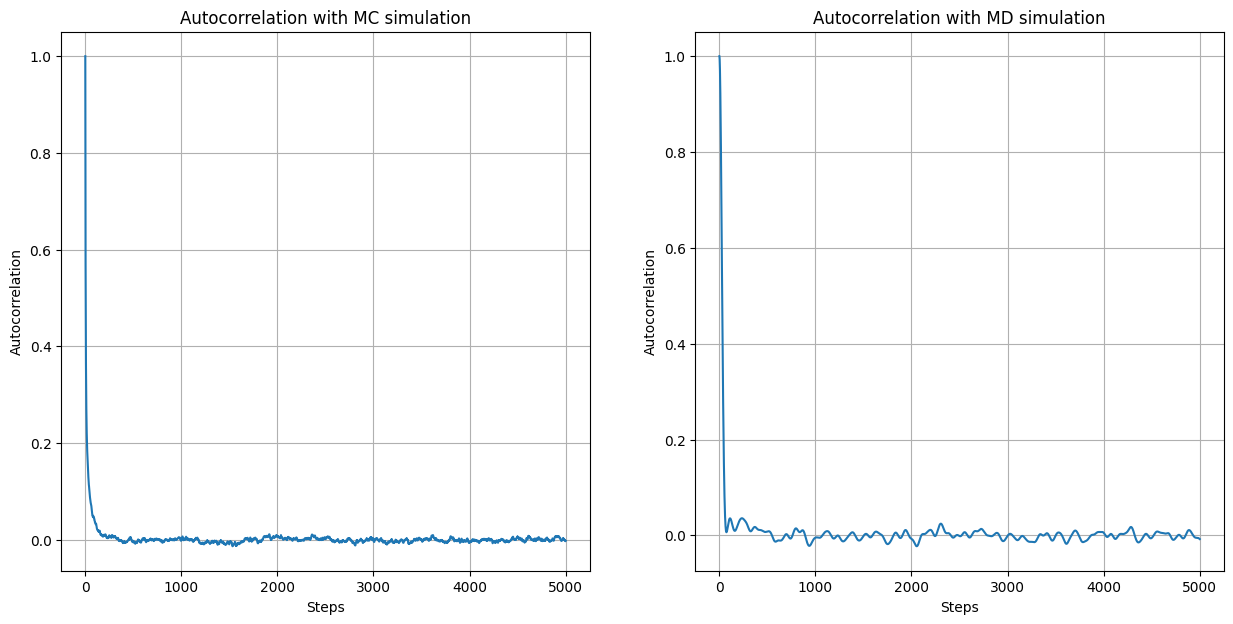

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))

axs[0].plot(steps[:tmax], autocorrelation_MC)
axs[1].plot(steps[:tmax], autocorrelation_MD)

axs[0].set_title("Autocorrelation with MC simulation")
axs[0].set_ylabel("Autocorrelation")
axs[0].set_xlabel("Steps")
axs[0].grid()

axs[1].set_title("Autocorrelation with MD simulation")
axs[1].set_ylabel("Autocorrelation")
axs[1].set_xlabel("Steps")
axs[1].grid()

In [ ]:
def error(L, data):
    N = int(len(data)//L)
    """ averages = np.zeros(N)
    for i in range(N):
        averages[i] = np.sum(data[i*L:(i+1)*L]) """
    averages = np.array([np.sum(data[i*L:(i+1)*L]) / L for i in range(N)])
    sum_averages = np.sum(averages) / N
    sum_averages2 = np.sum(averages * averages) / N
    return math.sqrt((sum_averages2-np.power(sum_averages,2))/(N-1))

In [ ]:
print(1//2)

0


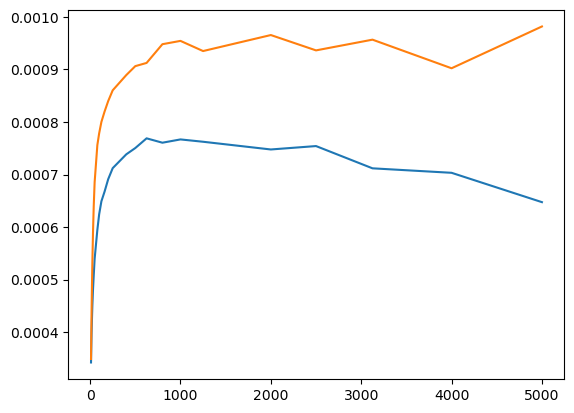

In [ ]:
#L = np.linspace(10,5000)
L = np.array( [n for n in range(10, 5001) if int(steps[-1])%n == 0] ) # Array of all divisors of the number of data less or equal to 5000

errors_MC = [error(int(l), energy_MC) for l in L]
errors_MD = [error(int(l), energy_MD) for l in L]

plt.plot(L, errors_MC);
plt.plot(L, errors_MD);

## Exercise 07.4

Per MD 20000 step di equilibrazione, temp=2

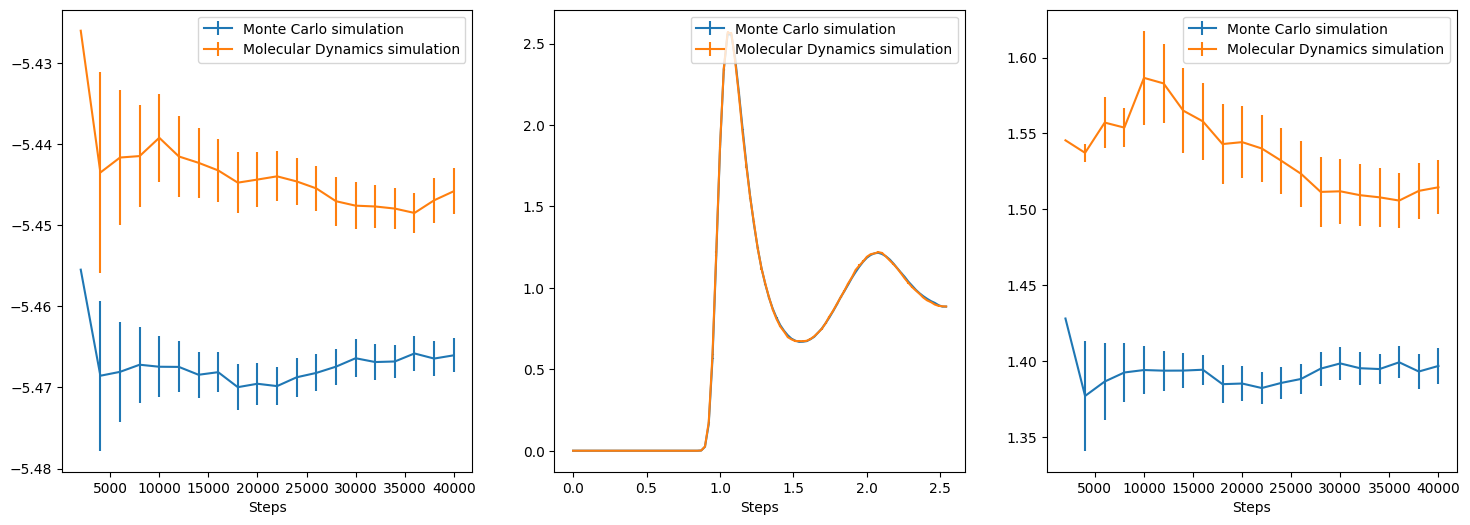

In [ ]:
energy_MC = np.loadtxt("../NSL_SIMULATOR/OUTPUT_07.4_1/potential_energy.dat", usecols=(2,3))
pressure_MC = np.loadtxt("../NSL_SIMULATOR/OUTPUT_07.4_1/pressure.dat", usecols=(2,3))
data_gofr_MC = np.loadtxt("../NSL_SIMULATOR/OUTPUT_07.4_1/gofr.dat")
r, gofr_MC = data_gofr_MC[:,0], data_gofr_MC[:,1:]
blocks = (np.arange(len(energy_MC)) + 1) * 2000

energy_DM = np.loadtxt("../NSL_SIMULATOR/OUTPUT_07.4_2/potential_energy.dat", usecols=(2,3))
pressure_DM = np.loadtxt("../NSL_SIMULATOR/OUTPUT_07.4_2/pressure.dat", usecols=(2,3))
gofr_DM = np.loadtxt("../NSL_SIMULATOR/OUTPUT_07.4_2/gofr.dat", usecols=(1,2))

fig, axs = plt.subplots(1, 3, figsize=(18,6))
axs = axs.flatten()

axs[0].errorbar(blocks, energy_MC[:,0], yerr=energy_MC[:,1], label="Monte Carlo simulation")
axs[0].errorbar(blocks, energy_DM[:,0], yerr=energy_DM[:,1], label="Molecular Dynamics simulation")
axs[0].set_ylabel("Potential energy")

axs[1].errorbar(r, gofr_MC[:,0], yerr=gofr_MC[:,1], label="Monte Carlo simulation")
axs[1].errorbar(r, gofr_DM[:,0], yerr=gofr_DM[:,1], label="Molecular Dynamics simulation")

axs[2].errorbar(blocks, pressure_MC[:,0], yerr=pressure_MC[:,1], label="Monte Carlo simulation")
axs[2].errorbar(blocks, pressure_DM[:,0], yerr=pressure_DM[:,1], label="Molecular Dynamics simulation")

for ax in axs:
    ax.set_xlabel("Steps")
    ax.legend();